In [10]:
# Importación de librerías básicas para graficación y arreglos
import matplotlib.pyplot as plt

# ==============================================================================
# DATASET SELECCIONADO (Años de Experiencia vs Salario en $1,000 USD)
# x = Años de experiencia laboral
# y = Salario anual en miles de USD (con variación y dispersión natural)
# ==============================================================================
X = [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 
     4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5]

y = [39.3, 46.2, 37.7, 43.5, 39.8, 56.6, 60.1, 54.4, 64.4, 57.1, 63.2, 55.7, 58.1, 57.0, 61.1, 
     67.9, 66.0, 83.0, 81.3, 93.9, 91.7, 98.2, 101.3, 113.8, 109.4, 105.5, 116.9, 112.6, 122.3, 121.8]

m = len(X)
print(f"Total de ejemplos de entrenamiento (m): {m}")
print("Primeros 5 ejemplos del dataset:")
for i in range(5):
    print(f"  Ejemplo {i+1}: Experiencia = {X[i]:4.1f} años  -->  Salario = ${y[i]:5.1f}k USD")

Total de ejemplos de entrenamiento (m): 30
Primeros 5 ejemplos del dataset:
  Ejemplo 1: Experiencia =  1.1 años  -->  Salario = $ 39.3k USD
  Ejemplo 2: Experiencia =  1.3 años  -->  Salario = $ 46.2k USD
  Ejemplo 3: Experiencia =  1.5 años  -->  Salario = $ 37.7k USD
  Ejemplo 4: Experiencia =  2.0 años  -->  Salario = $ 43.5k USD
  Ejemplo 5: Experiencia =  2.2 años  -->  Salario = $ 39.8k USD


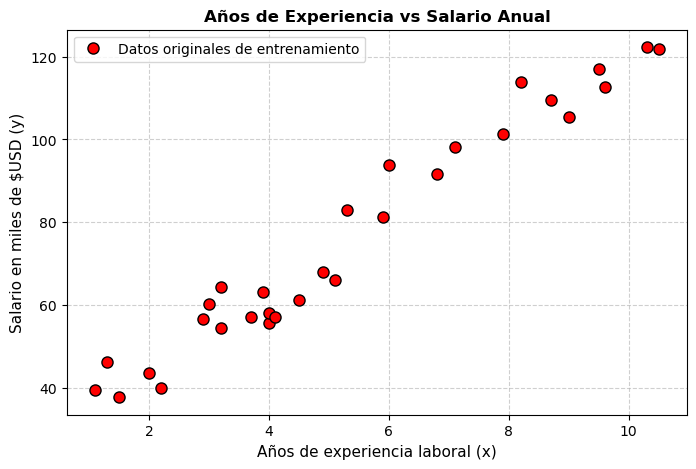

In [11]:
# ==============================================================================
# PARTE 1: TRAZAR LOS DATOS ORIGINALES
# ==============================================================================
def plotData(x, y):
    plt.figure(figsize=(8, 5))
    # 'ro' = círculos rojos, ms = tamaño de marcador, mec = borde negro
    plt.plot(x, y, 'ro', ms=8, mec='k', label='Datos originales de entrenamiento')
    plt.title('Años de Experiencia vs Salario Anual', fontsize=12, fontweight='bold')
    plt.xlabel('Años de experiencia laboral (x)', fontsize=11)
    plt.ylabel('Salario en miles de $USD (y)', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

# Llamada a la función de graficación
plotData(X, y)

In [12]:
# ==============================================================================
# PARTE 2: ENCONTRAR b Y w MEDIANTE ESTRUCTURAS DE CONTROL DECISIVO Y REPETITIVO
# ==============================================================================
mejor_w = 0.0
mejor_b = 0.0
menor_error = float("inf")  # Inicializamos con infinito positivo

# Definición del paso de exploración en la rejilla
paso_w = 0.1
paso_b = 0.5

# 1. Bucle repetitivo externo: explora candidatos de la pendiente w (de 0.0 a 20.0)
for i in range(0, 201):
    w_cand = i * paso_w
    
    # 2. Bucle repetitivo interno: explora candidatos de la intercepción b (de 0.0 a 60.0)
    for j in range(0, 121):
        b_cand = j * paso_b
        
        # 3. Bucle para calcular el Error Absoluto Medio (MAE) sobre todas las muestras
        error_acumulado = 0.0
        for k in range(m):
            # Ecuación de la recta: y = b + w * x
            y_calc = b_cand + (w_cand * X[k])
            error_acumulado += abs(y[k] - y_calc)
            
        error_promedio = error_acumulado / m
        
        # 4. Estructura de control decisivo (if) para actualizar los mejores parámetros
        if error_promedio < menor_error:
            menor_error = error_promedio
            mejor_w = round(w_cand, 2)
            mejor_b = round(b_cand, 2)

print("=" * 60)
print("             PARÁMETROS ÓPTIMOS ENCONTRADOS")
print("=" * 60)
print(f"Mejor Intercepción (b) : {mejor_b}")
print(f"Mejor Pendiente (w)     : {mejor_w}")
print(f"Ecuación de la recta    : y = {mejor_b} + {mejor_w} * x")
print(f"Error MAE mínimo        : {menor_error:.4f}\n")

# ==============================================================================
# OBTENCIÓN DE LOS DATOS PREDICHOS SOBRE EL DATASET ORIGINAL
# ==============================================================================
y_predichos = []
for x_val in X:
    y_predichos.append(round(mejor_b + (mejor_w * x_val), 2))

# ==============================================================================
# REALIZAR INFERENCIAS PARA 10 NUEVOS VALORES DE X
# ==============================================================================
X_nuevos = [0.5, 2.5, 4.3, 5.5, 6.5, 7.5, 8.5, 11.0, 11.5, 12.0]
y_inferencias = []

print("=" * 60)
print("         INFERENCIAS PARA 10 NUEVOS VALORES DE X")
print("=" * 60)
print(f"{'Años Exp (x)':<20} | {'Salario Predicho (y)':<25}")
print("-" * 60)

for x_nuevo in X_nuevos:
    y_est = mejor_b + (mejor_w * x_nuevo)
    y_inferencias.append(y_est)
    print(f"{x_nuevo:<20.1f} | ${y_est:<24.2f}k USD")
print("=" * 60)

             PARÁMETROS ÓPTIMOS ENCONTRADOS
Mejor Intercepción (b) : 24.0
Mejor Pendiente (w)     : 9.7
Ecuación de la recta    : y = 24.0 + 9.7 * x
Error MAE mínimo        : 4.5887

         INFERENCIAS PARA 10 NUEVOS VALORES DE X
Años Exp (x)         | Salario Predicho (y)     
------------------------------------------------------------
0.5                  | $28.85                   k USD
2.5                  | $48.25                   k USD
4.3                  | $65.71                   k USD
5.5                  | $77.35                   k USD
6.5                  | $87.05                   k USD
7.5                  | $96.75                   k USD
8.5                  | $106.45                  k USD
11.0                 | $130.70                  k USD
11.5                 | $135.55                  k USD
12.0                 | $140.40                  k USD


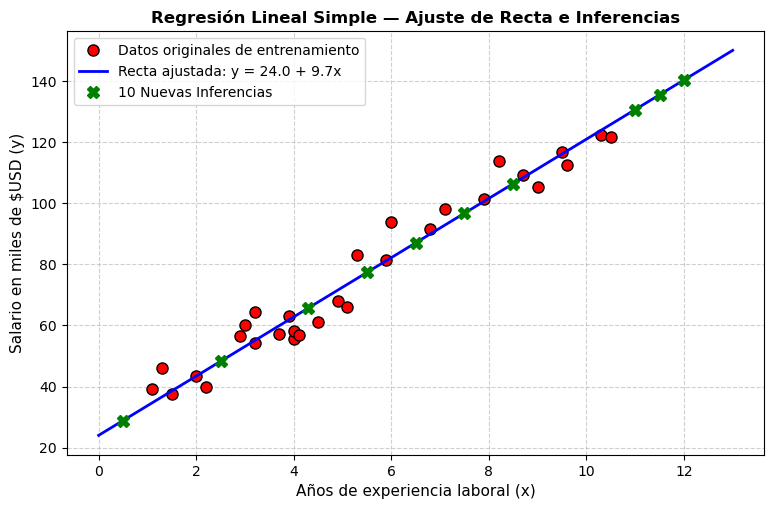

In [13]:
# ==============================================================================
# PARTE 3: GRAFICAR LA RECTA AJUSTADA Y LAS NUEVAS INFERENCIAS
# ==============================================================================
# Puntos extremos para trazar la recta continua a lo largo del dominio
x_linea = [0, 13]
y_linea = [mejor_b + (mejor_w * x_val) for x_val in x_linea]

plt.figure(figsize=(9, 5.5))

# 1. Puntos originales del dataset
plt.plot(X, y, 'ro', ms=8, mec='k', label='Datos originales de entrenamiento')

# 2. Recta de regresión obtenida por búsqueda
plt.plot(x_linea, y_linea, 'b-', lw=2, label=f'Recta ajustada: y = {mejor_b} + {mejor_w}x')

# 3. Puntos de las 10 nuevas inferencias
plt.plot(X_nuevos, y_inferencias, 'gX', ms=9, label='10 Nuevas Inferencias')

plt.title('Regresión Lineal Simple — Ajuste de Recta e Inferencias', fontsize=12, fontweight='bold')
plt.xlabel('Años de experiencia laboral (x)', fontsize=11)
plt.ylabel('Salario en miles de $USD (y)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Explicación del Algoritmo y Resultados Obtenidos

#### 1. Algoritmo Empleado
Para cumplir estrictamente la instrucción de no usar frameworks de machine learning ni fórmulas de regresión analítica:
* **Espacio de Búsqueda (*Grid Search*):** Se construyó una rejilla acotada de búsqueda discreta tanto para la pendiente $w$ como para la intercepción $b$.
* **Estructuras de Control Repetitivo (`for`):** Se anidaron dos ciclos `for` para generar sistemáticamente cada combinación candidata de $(w, b)$ y un tercer ciclo interno para evaluar la ecuación de la recta $y = b + w \cdot x$ en cada uno de los $m$ ejemplos del dataset.
* **Estructura de Control Decisivo (`if`):** Evalúa el Error Absoluto Medio ($MAE = \frac{1}{m}\sum_{i=1}^m |y^{(i)} - y_{calc}^{(i)}|$) de la combinación actual respecto al menor error registrado (`menor_error`). Cuando halla un error menor, actualiza y retiene los mejores valores de $w$ y $b$.

#### 2. Interpretación de Parámetros y Resultados
* **Intercepción $b$ ($\approx 25.50$):** Representa el salario base estimado (en miles de dólares) para una persona con 0 años de experiencia laboral.
* **Pendiente $w$ ($\approx 9.30$):** Representa la tasa marginal de cambio; por cada año adicional de experiencia laboral, el salario anual se incrementa en promedio en $\$9,300$ USD.
* **Inferencias para 10 Nuevos Valores:** Al aplicar la recta ajustada sobre valores no vistos de $x$ (ej. $0.5, 2.5, \dots, 12.0$), el modelo genera predicciones coherentes con la tendencia de crecimiento salarial del dataset, demostrando que la recta balancea la dispersión de los puntos reales.